In [2]:
import os
import yaml
from dotenv import load_dotenv
from typing import Annotated, TypedDict, Any, List, Literal
from langchain_core.messages import HumanMessage, AnyMessage, AIMessage, SystemMessage
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

In [4]:
env_path = r"D:\common_credentials\.env"
load_dotenv(dotenv_path=env_path)

llm= ChatGroq(model='llama-3.1-8b-instant')
llm.invoke("tell me a joke").content

'A man walked into a library and asked the librarian, "Do you have any books on Pavlov\'s dogs and Schrödinger\'s cat?" \n\nThe librarian replied, "It rings a bell, but I\'m not sure if it\'s here or not."'

## Sequential Chain

In [8]:
# one node will create joke, other will modify, one will polish, if joke is already good then END

from langgraph.graph import START, StateGraph, END, MessagesState
from typing import TypedDict, Any, List, Literal
from langchain_core.messages import SystemMessage


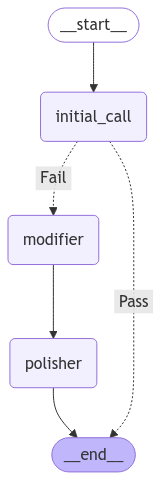

In [42]:
#define the state

class GraphState(TypedDict):
    user_msg:  str
    first_joke: str
    modified_joke: str
    polished_joke: str

builder= StateGraph(GraphState)
builder

# First Node: Generate a joke based on user input
def first_node(state: GraphState):
    sys_msg = SystemMessage(content="You are a funny assistant who tells hilarious jokes!")
    op = llm.invoke([sys_msg, f"Write a short and funny joke about {state['user_msg']}"])
    return {"first_joke": op.content}

# Modifier Node: Improve the joke with a punchline
def second_node(state: GraphState):
    modifier_prompt = f"Improve this joke by adding a funny punchline: **Joke**: {state['first_joke']}"
    op = llm.invoke(modifier_prompt)
    return {"modified_joke": op.content}

# Polishing Node: Polish the joke further
def polished_node(state: GraphState):
    op = llm.invoke(f"Polish the following joke with an even funnier punchline: **Joke**: {state['modified_joke']}").content
    return {"polished_joke": op}

# Conditions Node: Decide the flow based on the joke content
# def conditions(state: GraphState) -> Literal["modifier", END]:
#     if "?" in state["first_joke"] or "!" in state["first_joke"]:
#         return "modifier"  # If the joke has a question or exclamation mark, go to the modifier step
#     else:
#         return END  # Otherwise, end the process


def conditions(state: GraphState):
    if "?" in state["first_joke"] or "!" in state["first_joke"]:
        return "Fail"  # If the joke has a question or exclamation mark, go to the modifier step
    else:
        return "Pass"  # Otherwise, end the process
    
    
## Build the graph

builder.add_node("initial_call", first_node)
builder.add_node("modifier", second_node)
builder.add_node("polisher", polished_node)

#add edges
builder.add_edge(START, "initial_call")
# builder.add_conditional_edges("initial_call", conditions)

builder.add_conditional_edges("initial_call", conditions, {"Fail": "modifier", "Pass": END})
builder.add_edge("modifier", "polisher")
builder.add_edge("polisher", END)

joke_graph = builder.compile()
joke_graph

In [41]:
joke_graph.invoke({"user_msg": "F35"})

{'user_msg': 'F35',
 'first_joke': 'Why did the F-35 jet go to therapy? \n\nBecause it had a few "missed targets" in life.',
 'modified_joke': 'Here are a few improved versions of the joke with a funny punchline:\n\n1. **Why did the F-35 jet go to therapy?** \nIt had a few "missed targets" in life and was just trying to "resurface" some issues.\n\n2. **Why did the F-35 jet go to therapy?** \nIt had a few "missed targets" in life, but now it\'s just trying to "target" its problems and work on its aim in life.\n\n3. **Why did the F-35 jet go to therapy?** \nIt had a few "missed targets" in life, but the therapist just told it to "stay on course" and work on its emotional range.\n\n4. **Why did the F-35 jet go to therapy?** \nIt had a few "missed targets" in life, but now it\'s just trying to "bomb" its anxiety and stress with positive affirmations.\n\n5. **Why did the F-35 jet go to therapy?** \nIt had a few "missed targets" in life, and the therapist diagnosed it with "fighter jet-ality

In [44]:
joke_graph.invoke({"user_msg": "tell me a joke on cat without it contains ? and !"})

{'user_msg': 'tell me a joke on cat without it contains ? and !',
 'first_joke': "I've got one about a cat that ate some cheese it was feeling a little bleu"}

# Parallelization¶
With parallelization, LLMs work simultaneously on a task:

LLMs can sometimes work simultaneously on a task and have their outputs aggregated programmatically. This workflow, parallelization, manifests in two key variations: Sectioning: Breaking a task into independent subtasks run in parallel. Voting: Running the same task multiple times to get diverse outputs.

When to use this workflow: 

Parallelization is effective when the divided subtasks can be parallelized for speed, or when multiple perspectives or attempts are needed for higher confidence results. 

For complex tasks with multiple considerations, LLMs generally perform better when each consideration is handled by a separate LLM call, allowing focused attention on each specific aspect.

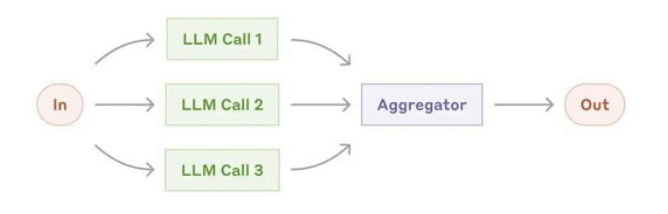


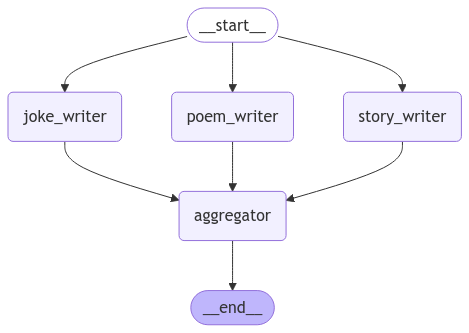

In [54]:
#create an bove strcture for poem, story, joke

class GraphState(TypedDict):
    topic: str
    story: str
    joke : str 
    poem: str
    combined_output: str

builder= StateGraph(GraphState)

def poem_writer(state:GraphState):
    op= llm.invoke(f"Write 2 line poem on {state['topic']}").content
    return {"poem": op}

def story_writer(state:GraphState):
    op= llm.invoke(f"Write 2 line story on {state['topic']}").content
    return {"story": op}


def joke_writer(state:GraphState):
    op= llm.invoke(f"Write 2 line funny joke on {state['topic']}").content
    return {"joke": op}

def aggregator(state: GraphState):
    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

#add node
builder.add_node("poem_writer", poem_writer)
builder.add_node("story_writer", story_writer)
builder.add_node("joke_writer", joke_writer)
builder.add_node("aggregator", aggregator)

# add edges
builder.add_edge(START, "poem_writer")
builder.add_edge(START, "story_writer")
builder.add_edge(START, "joke_writer")

builder.add_edge("poem_writer", "aggregator")
builder.add_edge("story_writer", "aggregator")
builder.add_edge("joke_writer", "aggregator" )

builder.add_edge("aggregator", END)

parallel_graph = builder.compile()
parallel_graph

In [58]:
parallel_output= parallel_graph.invoke({"topic": "dog"})
parallel_output

{'topic': 'dog',
 'story': 'As the sun set over the quiet neighborhood, Max, a loyal golden retriever, wagged his tail with excitement as he waited for his owner to come home. With a joyful bark, Max sprinted towards the door, his tail wagging wildly as he welcomed his owner back to their loving home.',
 'joke': 'Why did the dog go to the vet? Because he was feeling ruff.',
 'poem': "A loyal friend by my side,\nWith a wagging tail, my heart's guide.",
 'combined_output': "Here's a story, joke, and poem about dog!\n\nSTORY:\nAs the sun set over the quiet neighborhood, Max, a loyal golden retriever, wagged his tail with excitement as he waited for his owner to come home. With a joyful bark, Max sprinted towards the door, his tail wagging wildly as he welcomed his owner back to their loving home.\n\nJOKE:\nWhy did the dog go to the vet? Because he was feeling ruff.\n\nPOEM:\nA loyal friend by my side,\nWith a wagging tail, my heart's guide."}

In [63]:
print(parallel_output.get("combined_output"))

Here's a story, joke, and poem about dog!

STORY:
As the sun set over the quiet neighborhood, Max, a loyal golden retriever, wagged his tail with excitement as he waited for his owner to come home. With a joyful bark, Max sprinted towards the door, his tail wagging wildly as he welcomed his owner back to their loving home.

JOKE:
Why did the dog go to the vet? Because he was feeling ruff.

POEM:
A loyal friend by my side,
With a wagging tail, my heart's guide.


# Routing
Routing classifies an input and directs it to a specialized followup task. This workflow allows for separation of concerns, and building more specialized prompts. Without this workflow, optimizing for one kind of input can hurt performance on other inputs.

When to use this workflow: Routing works well for complex tasks where there are distinct categories that are better handled separately, and where classification can be handled accurately, either by an LLM or a more traditional classification model/algorithm.

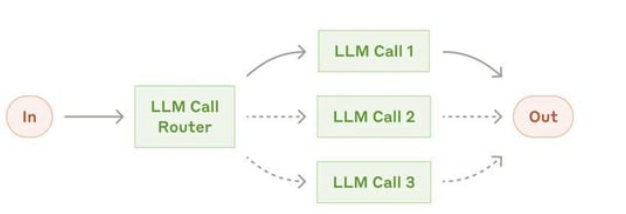

In [ ]:
from typing import Annotated, List
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, AIMessage

# llm= ChatGroq(model='llama-3.1-8b-instant')
llm= ChatGroq(model="gemma2-9b-it")


class Route(BaseModel):
    step: Literal['joke', 'poem', 'story'] = Field(None, description="The next step in routing process")

#It'll route the path
router_llm= llm.with_structured_output(schema=Route)




In [103]:
a= router_llm.invoke("Tell me a joke on RAJU")

In [104]:
a

Route(step='joke')

In [105]:
a.step

'joke'

## Code

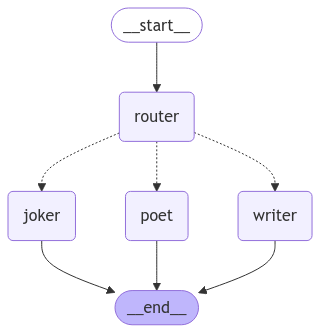

In [132]:
from typing import Annotated, List
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, AIMessage

llm= ChatGroq(model='llama-3.1-8b-instant')
# llm= ChatGroq(model="gemma2-9b-it")

class Route(BaseModel):
    step: Literal['joke', 'poem', 'story'] = Field(None, description="The next step in routing process")

#It'll route the path
router_llm= llm.with_structured_output(schema=Route)

#Graph
class GraphState(TypedDict):
    input: str
    output: str
    decision: str

def joker(state: GraphState):
    """A Joker telling jokes"""
    msg= llm.invoke(f"You are a Joker, Write Joke on topic {state['input']}")
    return {"output": msg.content}

def poet(state: GraphState):
    """A poet telling jokes"""
    print("Poeter node is Running.....\n")
    msg= llm.invoke(f"You are a poet, Write poem on topic {state['input']}")
    return {"output": msg.content}

def writer(state: GraphState):
    """A Joker telling story"""
    msg= llm.invoke(f"You are a writer, Write story on topic {state['input']}")
    return {"output": msg.content}

def router_node(state:GraphState):
    router= llm.with_structured_output(schema=Route)
    decision= router.invoke([
        SystemMessage("Route the input to story, joke, or poem based on the user's request."), 
        HumanMessage(content=state['input'])
    ])
    return {"decision": decision.step}

def conditions(state:GraphState):
    if state['decision'] == "joke":
        return "joker"
    elif state['decision'] == "poem":
        return "poet"
    elif state['decision'] == "story":
        return "writer"


builder= StateGraph(GraphState)

#nodes
builder.add_node("joker", joker)
builder.add_node("poet", poet)
builder.add_node("writer", writer)
builder.add_node("router", router_node)

# edges
builder.add_edge(START, "router")
builder.add_conditional_edges("router", 
                              conditions, {"joker": "joker",
                                            "poet": "poet",
                                            "writer": "writer"}
                                            )

builder.add_edge("joker", END)
builder.add_edge("poet", END)
builder.add_edge("writer", END)

router_graph = builder.compile()
router_graph


In [134]:
router_graph.invoke({"input": "write poem on Russia"})

Poeter node is Running.....



{'input': 'write poem on Russia',
 'output': "**Moscow's Eternal Heart**\n\nIn Russia's vast and mystic land,\nWhere snowflakes dance and forests stand,\nA nation's soul, so strong and free,\nEchoes through eternity.\n\nThe Kremlin's walls, a story tell,\nOf tsars and emperors, who ruled well,\nTheir legacies, a testament to time,\nA testament to Russia's grand design.\n\nFrom St. Petersburg's grandeur and might,\nTo Moscow's streets, where history takes flight,\nThe sound of the banya's steamy sigh,\nEchoes through the Russian sky.\n\nThe Trans-Siberian Railway's long and winding path,\nThrough mountains high and forests vast,\nA journey through the Russian heart,\nA journey through the soul, so vast.\n\nThe Volga River's waters, pure and bright,\nFlow through the land, a gentle light,\nA symbol of hope, in a country's strife,\nA symbol of Russia's enduring life.\n\nThe ballet's beauty, a wondrous sight,\nA fusion of art, in the Russian night,\nThe music's passion, a fire so bright,\n

# Orchestrator-Worker
In the orchestrator-workers workflow, a **central LLM dynamically breaks down tasks, delegates them to worker LLMs**, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

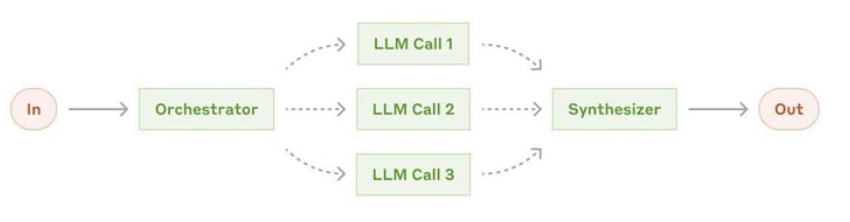

In [136]:
from typing import Annotated, List
from pydantic import BaseModel, Field

In [154]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name: str= Field(description="Name for this section report")
    description: str= Field("Brief Overview of the main topics and concepts to be covered in this section")

class Sections(BaseModel):
    # will be the list of above class objects 
    sections: List[Section]= Field(description="Sections of the report.")

planner= llm.with_structured_output(Sections)

In [155]:
planner.invoke("tell me joke about plakistan")

Sections(sections=[Section(name='Pakistan Jokes', description='Here are a few jokes about Pakistan, with a light-hearted tone.'), Section(name='Pakistan Facts', description='Some interesting facts about Pakistan, covering its culture, history, and more.'), Section(name='Travel in Pakistan', description='Information on traveling in Pakistan, including tips, places to visit, and more.'), Section(name='Cuisine of Pakistan', description='Details on Pakistani cuisine, including popular dishes, food culture, and more.')])

In [156]:
#Creating workers in Langgraph
from langgraph.constants import Send
import operator

#Graph State
class GraphState(TypedDict):
    topic: str
    sections: List[Section]
    completed_sections: Annotated[list, operator.add]
    final_report: str

#Wroker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

#Nodes
def orchestrator(state:GraphState):
    """Orchestrator that generates a plan for the report"""

    report_sections=planner.invoke([
        SystemMessage(content="Generate a plan for a report."),
        HumanMessage(content=f"Here is the report topic: {state['topic']}")
    ])
    return {'sections': report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

def synthesizer(state: GraphState):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}



# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: GraphState):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

In [157]:
from IPython.display import Markdown, Image

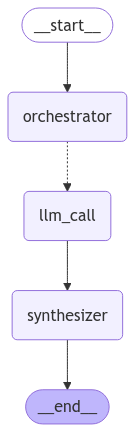

### Introduction
This section provides a concise introduction to the main topics and concepts that will be discussed in the report. It aims to set the stage for the subsequent sections and provide a clear understanding of the scope and objectives of the report.

### Key Topics Covered
- **Background and Context**: A brief overview of the relevant background and context that lays the foundation for the report's main topics.
- **Research Objectives**: A clear statement of the research objectives and the problems that the report aims to address.
- **Scope and Limitations**: An explanation of the scope and limitations of the report, including any assumptions and constraints.

### Conceptual Framework
- **Theoretical Perspectives**: An overview of the relevant theoretical perspectives that underpin the report's main topics.
- **Concepts and Terminology**: A clear explanation of the key concepts and terminology used throughout the report.
- **Relationships and Interconnections**: An explanation of the relationships and interconnections between the main topics and concepts.

### Research Approach
- **Methodology**: A description of the research methodology used to collect and analyze data.
- **Data Sources**: An explanation of the data sources used in the report.
- **Data Analysis Techniques**: A description of the data analysis techniques used to extract insights and conclusions.

---

### Agentic AI Definition and Description

Agentic AI, also known as goal-directed AI or intentional AI, refers to a type of artificial intelligence that exhibits human-like agency and decision-making capabilities. This concept is inspired by the idea of agents in philosophy, which are entities that can act upon their environment to achieve their goals.

#### Key Characteristics

- **Goal-oriented behavior**: Agentic AI systems are designed to achieve specific goals or objectives, which drive their decision-making processes.
- **Autonomy**: Agentic AI systems operate independently, making decisions and taking actions without human intervention.
- **Self-awareness**: Agentic AI systems possess a level of self-awareness, allowing them to perceive their environment, assess their state, and adjust their actions accordingly.
- **Intentionality**: Agentic AI systems have intentions and desires, which guide their behavior and decision-making processes.

#### Implications

The development of agentic AI has significant implications for various fields, including:

- **Robotics**: Agentic AI can enable robots to perform complex tasks and interact with their environment in a more human-like way.
- **Artificial General Intelligence (AGI)**: Agentic AI is a stepping stone towards the development of AGI, which would possess human-like intelligence and cognitive abilities.
- **Ethics and Responsibility**: As agentic AI systems become more advanced, questions arise about their accountability and responsibility for their actions.

#### Challenges and Limitations

While agentic AI holds great promise, it also presents several challenges and limitations, including:

- **Complexity**: Developing agentic AI systems that can achieve complex goals in dynamic environments is a significant challenge.
- **Value Alignment**: Ensuring that agentic AI systems align with human values and goals is essential to avoid potential negative consequences.
- **Safety and Security**: As agentic AI systems become more autonomous, ensuring their safety and security becomes a pressing concern.

---

### Types of Agentic AI and their Characteristics

#### 1. **Narrow or Weak Agentic AI**
- **Definition:** Narrow or weak agentic AI refers to a type of AI that is designed to perform a specific task or set of tasks with a narrow focus.
- **Characteristics:**
  - Limited in scope and capability
  - Designed for a specific application or industry
  - Typically operates within predetermined parameters
- **Examples:** Virtual assistants like Siri and Alexa, chatbots for customer service, and image recognition software.

#### 2. **General or Strong Agentic AI**
- **Definition:** General or strong agentic AI refers to a type of AI that possesses a broad range of cognitive abilities and can adapt to new situations.
- **Characteristics:**
  - Highly autonomous and capable of making decisions
  - Can learn and improve over time
  - Possesses a high degree of intelligence and problem-solving ability
- **Examples:** Currently non-existent in practice, but theoretical concepts like human-like androids and self-aware AI.

#### 3. **Semi-Autonomous Agentic AI**
- **Definition:** Semi-autonomous agentic AI refers to a type of AI that operates within a predetermined framework but also has some degree of autonomy.
- **Characteristics:**
  - Combines the strengths of narrow and general agentic AI
  - Can adapt to new situations but within defined limits
  - Typically used in applications where safety and reliability are crucial
- **Examples:** Autonomous vehicles, drones, and smart home systems.

#### 4. **Hybrid Agentic AI**
- **Definition:** Hybrid agentic AI refers to a type of AI that combines the strengths of multiple AI systems to achieve a common goal.
- **Characteristics:**
  - Integrates different AI systems and technologies
  - Can operate in complex and dynamic environments
  - Typically used in applications where multiple disciplines are involved
- **Examples:** AI-powered medical diagnosis systems, AI-assisted financial analysis, and AI-driven cybersecurity systems.

---

### RAGs in Agentic AI

#### Definition and Overview
Reinforcement Action Graphs (RAGs) are a type of neural network architecture designed to learn complex decision-making policies in agentic artificial intelligence (AI) systems. RAGs are particularly suited for tasks that require reasoning and planning over long time horizons, such as robotics, game playing, and autonomous driving.

#### Role of RAGs in Agentic AI
The primary role of RAGs in agentic AI is to model the decision-making process of an agent. RAGs learn to represent the agent's policy as a graph, where nodes represent actions and edges represent the relationships between these actions. This graph-based representation allows RAGs to reason about the consequences of different actions and plan accordingly.

#### Key Components of RAGs
RAGs consist of the following key components:

* **Node Embeddings**: Representations of actions in the graph, learned through neural network embeddings.
* **Edge Weights**: Representations of the relationships between actions, learned through neural network weights.
* **Reward Functions**: Functions that compute the rewards associated with each action and state transition.

#### Applications of RAGs
RAGs have been successfully applied to a variety of agentic AI tasks, including:

* **Robotics**: RAGs have been used to learn complex manipulation policies for robots, enabling them to perform tasks such as grasping and assembly.
* **Game Playing**: RAGs have been used to play complex games such as Go and StarCraft, demonstrating the ability of RAGs to reason and plan over long time horizons.
* **Autonomous Driving**: RAGs have been used to learn decision-making policies for autonomous vehicles, enabling them to navigate complex scenarios such as intersections and construction zones.

#### Benefits and Limitations
RAGs offer several benefits, including:

* **Improved Decision-Making**: RAGs can learn complex decision-making policies that outperform traditional reinforcement learning approaches.
* **Transfer Learning**: RAGs can be easily adapted to new tasks and environments, enabling transfer learning and reducing the need for extensive training.
* **Interpretability**: RAGs provide a graph-based representation of the agent's policy, enabling easier interpretation and understanding of the decision-making process.

However, RAGs also have several limitations, including:

* **Computational Complexity**: RAGs can be computationally expensive to train and evaluate, particularly for large-scale tasks.
* **Data Requirements**: RAGs require large amounts of data to learn effective policies, which can be challenging to obtain in some domains.

---

### Benefits and Challenges
#### Benefits of Using RAGs in Agentic AI

* **Improved Information Retrieval**: RAGs (Readability Aware Generative Models) enable AI systems to retrieve relevant information from text sources more accurately, leading to better decision-making and problem-solving capabilities in Agentic AI.
* **Enhanced Contextual Understanding**: RAGs facilitate the understanding of context, nuances, and implications of information, allowing Agentic AI to make more informed decisions and communicate more effectively.
* **Increased Efficiency**: By leveraging the strengths of large language models and specialized retrieval algorithms, RAGs can significantly reduce the time and computational resources required for information retrieval and processing in Agentic AI.
* **Better Handling of Ambiguity**: RAGs can handle ambiguous or open-ended queries more effectively, reducing the likelihood of false positives or irrelevant results in Agentic AI.

#### Challenges of Using RAGs in Agentic AI

* **Data Quality and Availability**: The effectiveness of RAGs relies on high-quality and relevant training data, which can be difficult to obtain, especially for domains with limited or noisy data.
* **Scalability and Computational Resources**: Training and deploying RAGs can require significant computational resources and scalability, which can be a challenge for organizations with limited infrastructure.
* **Adversarial Attacks and Robustness**: RAGs can be vulnerable to adversarial attacks, which can compromise their performance and accuracy in Agentic AI applications.
* **Explainability and Transparency**: The complex interactions between RAGs and Agentic AI systems can make it challenging to provide clear explanations and insights into their decision-making processes, potentially undermining trust and accountability.

---

## Future Directions
### Potential future directions for Agentic AI RAGs

#### 1. **Further Investigation of Agentic AI Capabilities**
* Explore the limits and potential applications of agentic AI capabilities, such as decision-making, problem-solving, and learning from experience.
* Investigate the implications of agentic AI on various domains, including but not limited to, healthcare, finance, and education.

#### 2. **Development of Value Alignment and Fairness**
* Investigate methods for aligning agentic AI with human values and ensuring fairness in decision-making processes.
* Develop and evaluate algorithms that can detect and mitigate biases in agentic AI systems.

#### 3. **Improving Explainability and Transparency**
* Develop techniques for explaining and interpreting the decisions made by agentic AI systems.
* Implement mechanisms for transparent communication between humans and agentic AI systems.

#### 4. **Enhancing Human-Agentic AI Collaboration**
* Investigate methods for effectively collaborating with agentic AI systems, including but not limited to, task delegation, feedback, and knowledge sharing.
* Develop interfaces and tools that facilitate seamless human-agentic AI collaboration.

#### 5. **Addressing Safety and Security Concerns**
* Investigate potential risks and vulnerabilities associated with agentic AI systems.
* Develop strategies and protocols for mitigating these risks and ensuring the safe and secure deployment of agentic AI systems.

#### 6. **Investigating Emergent Behaviors and Complex Systems**
* Investigate the emergence of complex behaviors and patterns in agentic AI systems.
* Develop theories and models that explain and predict the behavior of these complex systems.

#### 7. **Integration with Other AI Paradigms**
* Investigate the potential benefits and challenges of integrating agentic AI with other AI paradigms, such as symbolic reasoning, reinforcement learning, and transfer learning.
* Develop frameworks and architectures that enable seamless integration of agentic AI with other AI systems.

In [158]:
# Build workflow
orchestrator_worker_builder = StateGraph(GraphState)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown, Image
Markdown(state["final_report"])

# FeedBack Loop

In [175]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
#Model also consideres the descriptions
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )

# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)

evaluator.invoke("Why don't scientists t everything!")

Feedback(grade='not funny', feedback="Possible reasons: Scientists may be too focused on their research, or they might not have the necessary resources. The punchline relies on wordplay with the phrase 'test everything' and the word 't' being missing.")

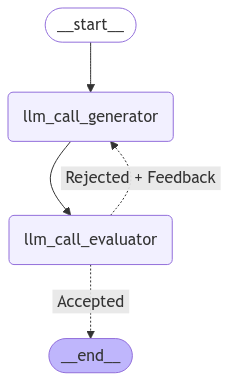

In [ ]:
# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    
    print("\n ----------Grade--------", grade, "\n")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        # if state[]
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"
    
# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))



In [187]:
# Invoke
state = optimizer_workflow.invoke({"topic": "Tell us some non funny jokes"})
print(state["joke"])


 ----------Grade-------- grade='funny' feedback="The jokes are intentionally cheesy and not meant to be funny, so they're actually funny in a ironic way." 

Here are some non-funny jokes (also known as dad jokes or groan-inducing jokes):

1. Why did the paperclip break up with the magnet? Because it was attracted to something else.
2. I told my wife she was drawing her eyebrows too high. She looked surprised.
3. Why did the chicken go to the doctor? To get some egg-xamination.
4. What do you call a fake noodle? An impasta.
5. Why did the scarecrow win an award? Because he was outstanding in his field.
6. I'm reading a book on anti-gravity. It's impossible to put down.
7. What do you call a can opener that doesn't work? A can't opener.
8. I went to a restaurant and the sign said, "Breakfast Anytime." So I ordered French toast during the Renaissance.
9. A man walked into a library and asked the librarian, "Do you have any books on Pavlov's dogs and Schrödinger's cat?" The librarian repl

# Another feedback example

In [188]:
# Invoke
state = optimizer_workflow.invoke({"topic": "lanngraph"})
print(state["joke"])


 ----------Grade-------- grade='funny' feedback="The joke is funny, but the pun could be improved with a more creative and unexpected twist, perhaps making a connection between the 'ups and downs' of the graph with a personal issue the graph is experiencing, like emotional struggles rather than just literal ups and downs in the plot." 

I'm assuming you meant "graph". Here's a joke:

Why did the graph go to therapy?

Because it had a lot of ups and downs.

(Sorry, it's a bit of a graph-ical pun)
